# Introduction

**Goal:** Generate plausible peptides with high antimicrobial activity.

To find such peptides, we will need two things:
- 🗺️ **A Map**, which will describe a landscape of plausible peptides.
- 🧭 **A Compass**, which will guide us toward peptides with high antimicrobial activity. 


The **Map** will be provided by the latent space of the variational autoencoder [HydrAMP (Szymczak et al., 2023)](https://doi.org/10.1038/s41467-023-36994-z). 

The **Compass** will be an antimicrobial activity predictor, namely APEX [Wan et al., 2024](https://doi.org/10.1038/s41551-024-01201-x)

Plan:
1. 🗺️ Get familiar with the "map" - HydrAMP autoencoder
2. 🧭 Get familiar with the "compass" - APEX predictor
3. ✈️ Global exploration and Optimization
4. 📍 Local Exploration and Optimization



# Installation

TODO: create installation guideline
- needed packages
- CPU or GPU environment in google colab

In [92]:
import warnings

import logomaker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
from Levenshtein import distance
from sklearn.decomposition import PCA

from pep_compass.autoencoder.factory import AutoencoderFactory
from pep_compass.autoencoder.strategies.hydramp.adapter import HydrampAutoencoder
from pep_compass.data.optimization import CandidateBatch
from pep_compass.optimization.components.mutation_generators.strategies.mutang.combination.baseline import (
    BaselineCombination,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.direction_selection.baseline import (
    BaselineDirectionSelection,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.geometry.kappa_stable import (
    KappaStableGeometry,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.mutang import (
    Mutang,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.mutation_selection.threshold import (
    ThresholdSelection,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.scoring.max_absolute_loading import (
    MaxAbsoluteLoading,
)
from pep_compass.optimization.components.oracles.strategies.apex.oracle import (
    APEXBlackBox,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.boundary.main import (
    MainBoundary,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.directions.active_inactive import (
    ActiveInactiveDirections,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.position_update.main import (
    MainPositionUpdate,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.scaling.stable_dimension import (
    StableDimensionScaling,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.sorbes import Sorbes
from pep_compass.optimization.engine.execution.context import OptimizationContext


# 🗺️ **The Map** - Autoencoder


TODO: Add some image with autoencoder archiotecture. From some presentations

In [2]:
autoencoder: HydrampAutoencoder = AutoencoderFactory.build(
    "hydramp",
    model="article_25",
    device="cpu",
    jacobian_eps=0.001,
    field_eps=0.001,
    jacobian_mode="approx",
)

/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Once we have the autoencoder in hand, let's embed peptides and visualize the latent space with PCA.

Let's also sample a few points from the latent space. 

In [3]:
# TODO: write correct path to the peptides.csv file. Remove absolute path.
PEPTIDE_DATASET_PATH = (
    "/home/adambiel/pep-compass/data/peptides_data/peptides_raw/peptides.csv"
)
peptide_dataset = pd.read_csv(PEPTIDE_DATASET_PATH)
background_peptides = peptide_dataset["sequence"].sample(10000, random_state=32).values

print("First 10 background peptides:")
background_peptides[:10]

First 10 background peptides:


array(['FLVTLGLNIVSGIVLKRYREVYQ', 'MLWRLVQQWSV', 'MSWKKALRIPGGLRAATVTLML',
       'AVHDRQAAELAWGRAIAFLKKRLG', 'IFMAVFKKRVVYTKYRHDRHAIK',
       'TMGNPKPSVSWVKGETVVKETARIA', 'QLLKKYKNKIISVALLAIYFFDYR',
       'MVDVAHLERMGRELKCPI', 'MLALNNNLLEGPIPLSIYQLVR',
       'MNMFTVLTSCSVWLNTQNCGT'], dtype=object)

In [4]:
latent_background = autoencoder.encode_peptides(background_peptides)
latent_background.shape

torch.Size([10000, 64])

In [5]:
PCA_COMPONENTS = (0, 1)  # PCA components to plot

pca = PCA(n_components=64)
latent_background_projected = pca.fit_transform(
    latent_background.detach().cpu().numpy()
)

# Mean and variance in PCA space
mean = np.zeros(pca.n_components_)
variance = pca.explained_variance_

# Sample PCA coordinates
n_samples = 5

sampled_latent_points = np.random.normal(
    loc=mean,
    scale=np.sqrt(variance),
    size=(n_samples, pca.n_components_),
)

fig = go.Figure()

background_lengths = [len(peptide) for peptide in background_peptides]

fig.add_trace(
    go.Scattergl(
        x=latent_background_projected[:, PCA_COMPONENTS[0]],
        y=latent_background_projected[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Background peptides",
        marker={
            "size": 6,
            "opacity": 0.5,
            "color": background_lengths,
            "colorscale": "Viridis",
            "colorbar": {
                "title": "Sequence length",
                "len": 0.5,
                "y": 0.5,
                "yanchor": "middle",
                "x": 1.02,
            },
        },
        customdata=[
            (sequence, length)
            for sequence, length in zip(background_peptides, background_lengths)
        ],
        hovertemplate=(
            "Sequence: %{customdata[0]}<br>"
            "Length: %{customdata[1]}<br>"
            f"PC{PCA_COMPONENTS[0]}: " + "%{x:.4f}<br>"
            f"PC{PCA_COMPONENTS[1]}: " + "%{y:.4f}<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Scattergl(
        x=sampled_latent_points[:, PCA_COMPONENTS[0]],
        y=sampled_latent_points[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Sampled latent points",
        marker={
            "size": 10,
            "opacity": 1,
            "color": "red",
        },
        hovertemplate=(
            "Sampled latent point<br>"
            f"PC{PCA_COMPONENTS[0]}: " + "%{x:.4f}<br>"
            f"PC{PCA_COMPONENTS[1]}: " + "%{y:.4f}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Interactive PCA projection of latent positions",
    xaxis_title=f"PC{PCA_COMPONENTS[0]} ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC{PCA_COMPONENTS[1]} ({pca.explained_variance_ratio_[1]:.1%} variance)",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()


Let's decode sampled latent points (red dots) and see how the point in the ambient space look like.

In [6]:
# Transform back to original space
latent_samples = pca.inverse_transform(sampled_latent_points)
latent_samples = torch.tensor(latent_samples, dtype=torch.float32)

with torch.inference_mode():
    ambient_decoded_samples = autoencoder.decoder_forward(
        latent_samples, softmax=True, flatten=False
    )

In [7]:
ambient_decoded_samples.shape

torch.Size([5, 25, 21])

- One ambient point is a tensor of size 25 x 21. 
- 25 correspond to maximum sequence length.
- 21 correspond to amino-acid alphabet with additional `<pad>` character

In [8]:
alphabet = ["<pad>"] + list("ACDEFGHIKLMNPQRSTVWY")
print(f"{alphabet=}")

alphabet=['<pad>', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


Let's visualize one ambient point as a table and let's inspect the content of entries.

One ambient point corresponds to a position-wise factorized probability distribution over the amino acid alphabet.
It means that on every position there is a categorical probability distribution.

In [9]:
SAMPLE_INDEX = (
    3  # Change this index to 0, 1, 2, 3, or 4 to visualize different sampled peptides
)

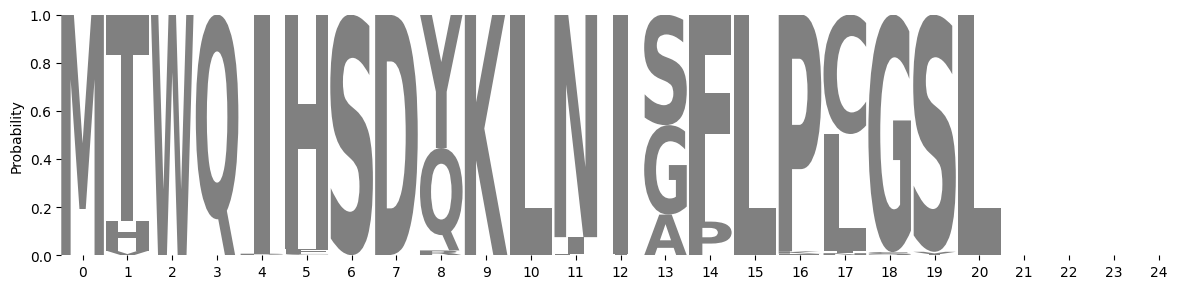

In [10]:
decoded_sample_numpy = ambient_decoded_samples[SAMPLE_INDEX].T.detach().cpu().numpy()

color_limit = 1

fig = go.Figure(
    go.Heatmap(
        z=decoded_sample_numpy,
        y=alphabet,
        colorscale="Greens",
        zmin=0,
        zmax=1,
        colorbar={"title": "Probability"},
        hovertemplate=(
            "Position: %{x}<br>Amino acid: %{y}<br>Probability: %{z:.2}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title=f"Soft peptide",
    xaxis_title="Peptide residue",
    yaxis_title="Alphabet",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

amino_acids = list(" ACDEFGHIKLMNPQRSTVWY")


def plot_logo(matrix, ax, title="", verbose=False):

    if not verbose:
        warnings.filterwarnings("ignore")
    df = pd.DataFrame(matrix.T, columns=amino_acids)
    df.index.name = "pos"

    logo = logomaker.Logo(df, ax=ax)
    logo.style_spines(visible=False)
    logo.style_xticks(anchor=0, spacing=1)

    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Probability")


plt.figure(figsize=(12, 3))
ax = plt.gca()
plot_logo(decoded_sample_numpy, ax=ax)
plt.tight_layout()
plt.show()

# 🧭 **The Compass** - APEX Predictor

The APEX model predicts a value called the **Minimal Inhibitory Concentration (MIC)**.

MIC represents the lowest concentration of a peptide required to stop bacterial growth. Therefore, lower MIC values indicate more active peptides. Our goal is thus to minimize the predicted MIC.

Exact MIC measurement requires wet lab validation. APEX predictor approximates MIC against several different bacteria, but we choose only three E. coli:
- $MIC_1$: E. coli ATCC 11775
- $MIC_2$: E. coli AIG221
- $MIC_3$: E. coli AIG222

Then we $log_2$ predicted $MIC_i$ values then we take mean. So the score is:

$$\frac{1}{3} \sum^3_{i=1} log_2 MIC_i$$


In [11]:
# Create the APEX predictor
apex_predictor = APEXBlackBox(
    model="default",
    device="cpu",
    mic_aggregate="mean",  # or "max"
    mic_bacteria=[1, 2, 3],  # Chooses only E. coli bacteria for scoring
    batch_size=64,
)

In [12]:
veltri_positive_dataset = peptide_dataset[
    peptide_dataset["dataset"].str.contains("hydramp_veltri_positive")
]
positive_sample = (
    veltri_positive_dataset["sequence"].sample(300, random_state=42).values
)

print("First 10 positive peptides:")
positive_sample[:10]

First 10 positive peptides:


array(['MRILSIIRWTRMKKSSA', 'GLHKVMREVLGYERNSYKKFFLR',
       'GVGDLIRKAVSVIKNIV', 'NLLNDALGTVNGLLGRS', 'AWRWKAFRNCWRVRSSSL',
       'FLSLALAALPKLFCLIFKKC', 'FLSLLPSIVSGAVSLAKKL',
       'GCSYSTRPYFLRWRLKFKSKVWCG', 'FLPGLIKAAVGVGSTILCKITKKC',
       'FIRWRFRWWRWRR'], dtype=object)

In [13]:
scores = apex_predictor.score(positive_sample.tolist())

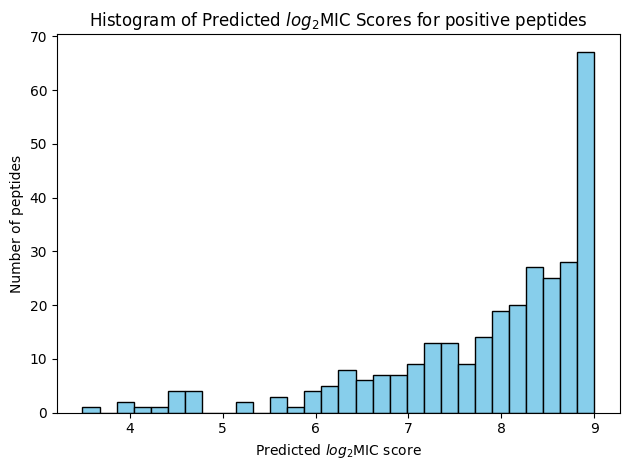

In [14]:
plt.hist(scores, bins=30, color="skyblue", edgecolor="black")

plt.xlabel("Predicted $log_2$MIC score")
plt.ylabel("Number of peptides")
plt.title("Histogram of Predicted $log_2$MIC Scores for positive peptides")

plt.tight_layout()
plt.show()

In [15]:
with torch.no_grad():
    latent_positive = autoencoder.encode_peptides(positive_sample)

In [16]:
projected_positive = pca.transform(latent_positive)

In [17]:
PCA_COMPONENTS = (0, 1)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scattergl(
        x=latent_background_projected[:, PCA_COMPONENTS[0]],
        y=latent_background_projected[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Background peptides",
        marker={
            "size": 6,
            "opacity": 0.2,
            "color": "gray",
        },
    )
)

fig.add_trace(
    go.Scattergl(
        x=projected_positive[:, PCA_COMPONENTS[0]],
        y=projected_positive[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Positive peptides",
        marker={
            "size": 12,
            "color": scores,
            "opacity": 0.8,
            "colorscale": "Viridis",
            "colorbar": {
                "title": "Log2MIC score",
                "len": 0.5,
                "y": 0.5,
                "yanchor": "middle",
                "x": 1.02,
            },
        },
        customdata=np.column_stack((positive_sample, scores)),
        hovertemplate=("Sequence: %{customdata[0]}<br>Score: %{customdata[1]:.4f}<br>"),
    )
)

fig.update_layout(
    title="Interactive PCA projection of latent positions",
    xaxis_title=f"PC{PCA_COMPONENTS[0]} ({pca.explained_variance_ratio_[PCA_COMPONENTS[0]]:.1%} variance)",
    yaxis_title=f"PC{PCA_COMPONENTS[1]} ({pca.explained_variance_ratio_[PCA_COMPONENTS[1]]:.1%} variance)",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

# ✈️ Global exploration and Optimization


1. Describe an idea.
    - two prototypes and interpolate between them. 
    - At the same time minimize the potential 
    - Add figure
    - Inspiration from airplanes

2. Choose a two prototypes with low MIC. Show their MIC.

In [18]:
start = "GLFDIAKKVIGVIGSL"
end = "WRSLGRTLLRLSCALKKLARRSGW"

In [19]:
start_score, end_score = apex_predictor.score([start, end])
print(f"log2 MIC score for the start sequence {start}: {start_score:.4f}")
print(f"log2 MIC score for the end sequence {end}: {end_score:.4f}")

log2 MIC score for the start sequence GLFDIAKKVIGVIGSL: 4.5491
log2 MIC score for the end sequence WRSLGRTLLRLSCALKKLARRSGW: 4.0161


3. Do linear interpolation between them.
4. Plot Linear interpolation (with background peptides?).
5. Plot MIC across the path.

In [20]:
start_latent = autoencoder.encode_peptides([start])[0]
end_latent = autoencoder.encode_peptides([end])[0]

In [21]:
POINTS_DENSITY = 90  # Number of points per unit distance in latent space
n_points = int(POINTS_DENSITY * torch.dist(end_latent, start_latent, p=2))

linear_interpolation = torch.stack(
    [
        start_latent + (i / (n_points - 1)) * (end_latent - start_latent)
        for i in range(n_points)
    ],
    dim=0,
)

with torch.inference_mode():
    decoded_linear_interpolation = autoencoder.decoder_forward(
        linear_interpolation, softmax=True, flatten=False
    )

interpolation_indices = decoded_linear_interpolation.argmax(dim=-1).cpu().numpy()

interpolation_sequences = []
for indices in interpolation_indices:
    sequence = "".join(alphabet[index] for index in indices)
    interpolation_sequences.append(sequence.split("<pad>", 1)[0])


projected_linear_interpolation = pca.transform(
    linear_interpolation.detach().cpu().numpy()
)


In [22]:
# TODO: Extract this function to a separate file and import it here. Also, add unit tests for this function.
def find_significant_changes_and_reversions(peptide_list):
    significant_indices = [0]
    reversion_indices = []

    previous_peptides = {}

    for i in range(1, len(peptide_list)):
        dist = distance(peptide_list[i - 1], peptide_list[i])

        if dist >= 1:
            significant_indices.append(i)

        for _, prev_peptide in previous_peptides.items():
            if (
                peptide_list[i] == prev_peptide
                and peptide_list[i] != peptide_list[i - 1]
            ):
                reversion_indices.append(i)
                break

        previous_peptides[i] = peptide_list[i]

    significant_indices.append(len(peptide_list) - 1)
    significant_indices = list(significant_indices)

    return significant_indices, reversion_indices

In [23]:
pd.unique(interpolation_sequences)

array(['GLFDIAKKVIGVIGSL', 'GLFDIAKKVIGVIGSLL', 'VLFDIAKKVIGVIGSLL',
       'VLHDIAKKVIGVIGSLL', 'VNHDIAKKVIGVIGSLL', 'VNHDIAKKVIGVIGVLL',
       'VNHDIAKKVPGVIGVLL', 'VNHDIAKKVPGVIGVLLL', 'VNHDIGKKVPGVIGVLTL',
       'VNHDIGKKVPGVIAVLTL', 'VNHDIGKKVPGVFAVLTL', 'VNHDIGKKVPGVFAVLTN',
       'VNHEIGKKVPGVFAVLTN', 'HNHEIGKKVPGVFAVLTL', 'HNHEISKKVPGVFAVLTL',
       'HNHEISKKVPGVFAVLTLN', 'HNHEISKKVPGVFAVLTEN',
       'HNHETSKKVPGVFAVLTEN', 'HNHETSKKVPGVFAVLTSN',
       'HNHETVKKVPGVFAVLTSN', 'INHETVKKVPGVFAVLTSN',
       'IKHETVKKVPGVFAVLTSN', 'IKHETVKKVPGVFAVLTVN',
       'IKHETVKKVPGVFAVLLVN', 'IKHETVKKTPGVFAVLLVN',
       'IKHETVKKTPGVFAVLLSN', 'IKHETVKKTPGVFAVLLSL',
       'IKHETVKKTPGVFAVNLSL', 'IKVETVKKTPGVFAVNLGL',
       'IKVETVKKTPGVFAVNLGLK', 'IKVETTKKTPGVFAVNLGLK',
       'IKVETTKKTPGVFAVNLGEK', 'IKVETTKKTPGVFAVNLGDK',
       'IKVETTKKTPSVFAVNLGSK', 'IKVEVTKKTPSVFAVNLGSK',
       'IKVEVTKKTQSVFAVNLGSK', 'IKVEVTKKTQSVFAVNLVSK',
       'IKVEVTKKTQSVFAVNLVAK', 'IKVEVTNKTQSVFAVNLVAK

In [24]:
significant_indices, reversion_indices = find_significant_changes_and_reversions(
    interpolation_sequences
)

In [25]:
linear_interpolation_scores = apex_predictor.score(
    np.array(interpolation_sequences)[significant_indices].tolist()
)

In [26]:
unique_sequences, inverse_indices = np.unique(
    interpolation_sequences,
    return_inverse=True,
)

unique_scores = np.asarray(
    apex_predictor.score(unique_sequences.tolist()),
    dtype=np.float32,
)

# Restore scores to the original interpolation path order.
linear_interpolation_scores = unique_scores[inverse_indices]

print(f"Scored {len(unique_sequences)} unique sequences.")
print(f"Total path points: {len(interpolation_sequences)}")
print(linear_interpolation_scores.shape)

Scored 104 unique sequences.
Total path points: 683
(683,)


In [27]:
PCA_COMPONENTS = (0, 1)

fig = go.Figure()

fig.add_trace(
    go.Scattergl(
        x=latent_background_projected[:, PCA_COMPONENTS[0]],
        y=latent_background_projected[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Background peptides",
        hoverinfo="skip",
        marker={
            "size": 6,
            "opacity": 0.2,
            "color": "gray",
        },
    )
)


fig.add_trace(
    go.Scattergl(
        x=projected_linear_interpolation[:, PCA_COMPONENTS[0]],
        y=projected_linear_interpolation[:, PCA_COMPONENTS[1]],
        mode="lines+markers",
        name="Linear interpolation",
        line={"color": "black", "width": 2},
        marker={
            "size": 6,
            "color": linear_interpolation_scores,
            "colorscale": "Viridis",
            "showscale": True,
            "colorbar": {
                "title": "Log2MIC score",
                "len": 0.5,
                "y": 0.5,
                "yanchor": "middle",
                "x": 1.02,
            },
        },
        customdata=np.column_stack(
            (
                np.arange(n_points),
                interpolation_sequences,
                linear_interpolation_scores,
            )
        ),
        hovertemplate=(
            "Path point: %{customdata[0]}<br>"
            "Sequence: %{customdata[1]}<br>"
            "Log2MIC: %{customdata[2]:.4f}<extra></extra>"
        ),
    )
)

endpoint_projection = projected_linear_interpolation[[0, -1]]
endpoint_sequences = [start, end]
endpoint_scores = [start_score, end_score]
endpoint_names = ["Start", "End"]

fig.add_trace(
    go.Scattergl(
        x=endpoint_projection[:, PCA_COMPONENTS[0]],
        y=endpoint_projection[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Interpolation endpoints",
        marker={"size": 14, "color": ["green", "red"]},
        customdata=np.column_stack(
            (endpoint_names, endpoint_sequences, endpoint_scores)
        ),
        hovertemplate=(
            "%{customdata[0]}<br>"
            "Sequence: %{customdata[1]}<br>"
            "Log2MIC: %{customdata[2]:.4f}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Interactive PCA projection of latent positions",
    xaxis_title=f"PC{PCA_COMPONENTS[0]} ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC{PCA_COMPONENTS[1]} ({pca.explained_variance_ratio_[1]:.1%} variance)",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

In [28]:
fig = go.Figure(
    go.Scatter(
        x=np.arange(len(linear_interpolation_scores)),
        y=linear_interpolation_scores,
        mode="lines+markers",
        line={"color": "blue"},
        marker={"size": 6},
        customdata=list(zip(interpolation_sequences, linear_interpolation_scores)),
        hovertemplate=(
            "Path point: %{x}<br>"
            "Sequence: %{customdata[0]}<br>"
            "log2 MIC: %{customdata[1]:.4f}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Predicted log2 MIC along linear interpolation",
    xaxis_title="Interpolation point",
    yaxis_title="Predicted log2 MIC",
    template="plotly_white",
    width=900,
    height=500,
)

fig.show()

6. Do geodesic interpolation. Write equation. 
7. Plot geodesic interpolation (with linear interpolation and background peptides?).
8. Plot MIC across the path. (with linear interpolation)

9. Do POGS. Write equation.
10. Plot pogs interpolation (with linear and geodesic interpolation and background peptides)
11. Plot MIC across the path. (with linear interpolation and geodesic interpolation)

# 📍 Local Exploration and Optimization

TODO: make some introduction, intuition. 

Goal: search for neighbours

## 🐎 **MUTANG** - **MU**ation Enumeration in **TANG**ent Space


TODO:
Local coordinate system. SVD

In [29]:
peptide = 'IKALIRKWILRPIKRLKDKFWK'

peptide_latent = autoencoder.encode_peptides([peptide])
decoded_peptide = autoencoder.decode_peptides(peptide_latent)[0]
decoded_softpeptide = autoencoder.decoder_forward(peptide_latent, softmax=True, flatten=False)[0]

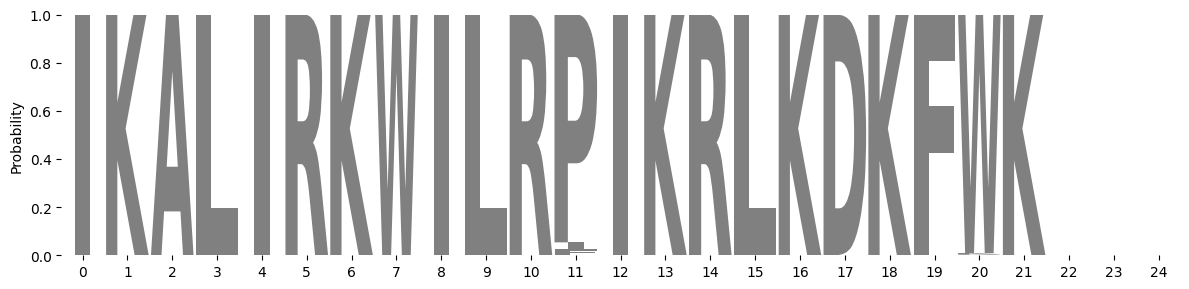

In [30]:
decoded_sample_numpy = decoded_softpeptide.T.detach().cpu().numpy()

color_limit = 1

fig = go.Figure(
    go.Heatmap(
        z=decoded_sample_numpy,
        y=alphabet,
        colorscale="Greens",
        zmin=0,
        zmax=1,
        colorbar={"title": "Probability"},
        hovertemplate=(
            "Position: %{x}<br>Amino acid: %{y}<br>Probability: %{z:.2}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title=f"Soft peptide",
    xaxis_title="Peptide residue",
    yaxis_title="Alphabet",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

amino_acids = list(" ACDEFGHIKLMNPQRSTVWY")


def plot_logo(matrix, ax, title="", verbose=False):

    if not verbose:
        warnings.filterwarnings("ignore")
    df = pd.DataFrame(matrix.T, columns=amino_acids)
    df.index.name = "pos"

    logo = logomaker.Logo(df, ax=ax)
    logo.style_spines(visible=False)
    logo.style_xticks(anchor=0, spacing=1)

    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Probability")


plt.figure(figsize=(12, 3))
ax = plt.gca()
plot_logo(decoded_sample_numpy, ax=ax)
plt.tight_layout()
plt.show()

In [31]:
jacobian = autoencoder.decoder_jacobian(peptide_latent)[0]
jacobian.shape

torch.Size([525, 64])

In [32]:
left, singular, right = torch.linalg.svd(
    jacobian,
    full_matrices=False,
)

In [33]:
print(f"{left.shape=}")
print(f"{right.shape=}")
print(f"{singular.shape=}")

left.shape=torch.Size([525, 64])
right.shape=torch.Size([64, 64])
singular.shape=torch.Size([64])


Let's inspect singular values.

In [34]:
SINGULAR_VALUE_THRESHOLD = 0.001

In [35]:
singular_values = singular.detach().cpu().numpy()

exponents = range(
    int(np.floor(np.log10(singular_values.min()))),
    int(np.ceil(np.log10(singular_values.max()))) + 1,
)

fig = go.Figure(
    go.Scatter(
        x=np.arange(len(singular_values)),
        y=singular_values,
        mode="lines+markers",
        customdata=singular_values,
        hovertemplate=(
            "Component: %{x}<br>"
            "Singular value: %{y:.6g}<br>"
            "<extra></extra>"
        ),
    )
)

fig.add_hline(
    y=SINGULAR_VALUE_THRESHOLD,
    line_dash="dot",
    line_color="red",
    # annotation_text="Threshold",
    # annotation_position="bottom right",
)

fig.update_layout(
    title="Singular values",
    xaxis_title="Component",
    yaxis_title="Singular value",
    width=800,
    yaxis={
        "type": "log",
        "tickvals": [10**e for e in exponents],
        "ticktext": [f"10<sup>{e}</sup>" for e in exponents],
    },
    template="plotly_white",
)

fig.show()

In [36]:
from plotly.subplots import make_subplots

selected_components = torch.where(singular > SINGULAR_VALUE_THRESHOLD)[0].tolist()

x_labels = list(decoded_peptide) + ["<pad>"] * (25 - len(decoded_peptide))

positions = np.arange(25)
customdata = np.zeros((len(alphabet), 25, 2), dtype=object)
customdata[:, :, 0] = positions
customdata[:, :, 1] = np.array(x_labels)

ncols = 3
first_component = selected_components[0]
remaining_components = selected_components[1:]
small_rows = int(np.ceil(len(remaining_components) / ncols))
nrows = 1 + small_rows

component_matrices = {
    component: (
        left[:, component]
        .reshape(25, len(alphabet))
        .T.detach()
        .cpu()
        .numpy()
    )
    for component in selected_components
}

global_color_limit = max(
    np.abs(matrix).max() for matrix in component_matrices.values()
)

subplot_titles = [
    f"Component {first_component} (σ={singular_values[first_component]:.3g})",
]

subplot_titles.extend(
    [
        f"Component {component} (σ={singular_values[component]:.3g})"
        for component in remaining_components
    ]
)
subplot_titles.extend([""] * (nrows * ncols - len(subplot_titles)))

specs = [[{"colspan": 3}, None, None]] + [
    [{"type": "heatmap"} for _ in range(ncols)]
    for _ in range(small_rows)
]

fig_grid = make_subplots(
    rows=nrows,
    cols=ncols,
    specs=specs,
    subplot_titles=subplot_titles,
    vertical_spacing=0.08,
    row_heights=[3] + [1] * small_rows,
)

def add_component_heatmap(component, row, col, showscale=False):
    matrix = component_matrices[component]

    component_customdata = np.empty((len(alphabet), 25, 2), dtype=object)
    component_customdata[:, :, 0] = positions
    component_customdata[:, :, 1] = np.array(x_labels)

    fig_grid.add_trace(
        go.Heatmap(
            z=matrix,
            x=positions,
            y=alphabet,
            colorscale="RdBu_r",
            zmid=0,
            zmin=-global_color_limit,
            zmax=global_color_limit,
            showscale=showscale,
            customdata=component_customdata,
            hovertemplate=(
                "Position: %{customdata[0]}<br>"
                "Residue: %{customdata[1]}<br>"
                "Alphabet: %{y}<br>"
                "Loading: %{z:.3f}<extra></extra>"
            ),
        ),
        row=row,
        col=col,
    )

# First singular vector: large, full-width plot.
add_component_heatmap(
    first_component,
    row=1,
    col=1,
    showscale=True,
)

# Remaining singular vectors: smaller grid.
for index, component in enumerate(remaining_components):
    row, col = divmod(index, ncols)
    add_component_heatmap(
        component,
        row=row + 2,
        col=col + 1,
    )

fig_grid.update_layout(
    title="Left singular vectors",
    template="plotly_white",
    width=900,
    height=800 + 230 * small_rows,
    xaxis={
        "tickmode": "array",
        "tickvals": np.arange(25),
        "ticktext": x_labels,
    },
)

fig_grid.show()


In [82]:
# If we lower a threshold we should expect:
# a) More mutants
# b) Less mutants
# Why?

POSITION_THRESHOLD = 0.1

In [83]:
geometry = KappaStableGeometry()
directions = BaselineDirectionSelection()
scoring = MaxAbsoluteLoading()
selection = ThresholdSelection(threshold=POSITION_THRESHOLD)
combination = BaselineCombination(alphabet=list(" ACDEFGHIKLMNPQRSTVWY"))

mutang = Mutang(
    geometry, directions, scoring, selection, combination, autoencoder=autoencoder
)

batch = CandidateBatch(
    sequences=[peptide],
    latent_origins=peptide_latent,
)

optimization_context = OptimizationContext(autoencoder=autoencoder)

mutants, options = mutang.generate(batch, optimization_context)[0]

positionwise_mutation_candidates = {index: {residue} for index, residue in enumerate(peptide)}
for option in options:
    positionwise_mutation_candidates[option.position].add(alphabet[option.residue])




In [84]:
positionwise_mutation_candidates

{0: {'I'},
 1: {'K'},
 2: {'A'},
 3: {'L'},
 4: {'I'},
 5: {'R'},
 6: {'K'},
 7: {'W'},
 8: {'I', 'P'},
 9: {'L'},
 10: {'R'},
 11: {'F', 'I', 'P'},
 12: {'I'},
 13: {'K'},
 14: {'R'},
 15: {'I', 'L'},
 16: {'K'},
 17: {'D', 'E', 'G', 'S'},
 18: {'K', 'W'},
 19: {'C', 'F', 'Y'},
 20: {'K', 'Q', 'W'},
 21: {'K'}}

In [85]:
len(mutants)

864

In [87]:
mutants

('IKALIRKWILRFIKRIKDKCKK',
 'IKALIRKWILRFIKRIKDKCQK',
 'IKALIRKWILRFIKRIKDKCWK',
 'IKALIRKWILRFIKRIKDKFKK',
 'IKALIRKWILRFIKRIKDKFQK',
 'IKALIRKWILRFIKRIKDKFWK',
 'IKALIRKWILRFIKRIKDKYKK',
 'IKALIRKWILRFIKRIKDKYQK',
 'IKALIRKWILRFIKRIKDKYWK',
 'IKALIRKWILRFIKRIKDWCKK',
 'IKALIRKWILRFIKRIKDWCQK',
 'IKALIRKWILRFIKRIKDWCWK',
 'IKALIRKWILRFIKRIKDWFKK',
 'IKALIRKWILRFIKRIKDWFQK',
 'IKALIRKWILRFIKRIKDWFWK',
 'IKALIRKWILRFIKRIKDWYKK',
 'IKALIRKWILRFIKRIKDWYQK',
 'IKALIRKWILRFIKRIKDWYWK',
 'IKALIRKWILRFIKRIKEKCKK',
 'IKALIRKWILRFIKRIKEKCQK',
 'IKALIRKWILRFIKRIKEKCWK',
 'IKALIRKWILRFIKRIKEKFKK',
 'IKALIRKWILRFIKRIKEKFQK',
 'IKALIRKWILRFIKRIKEKFWK',
 'IKALIRKWILRFIKRIKEKYKK',
 'IKALIRKWILRFIKRIKEKYQK',
 'IKALIRKWILRFIKRIKEKYWK',
 'IKALIRKWILRFIKRIKEWCKK',
 'IKALIRKWILRFIKRIKEWCQK',
 'IKALIRKWILRFIKRIKEWCWK',
 'IKALIRKWILRFIKRIKEWFKK',
 'IKALIRKWILRFIKRIKEWFQK',
 'IKALIRKWILRFIKRIKEWFWK',
 'IKALIRKWILRFIKRIKEWYKK',
 'IKALIRKWILRFIKRIKEWYQK',
 'IKALIRKWILRFIKRIKEWYWK',
 'IKALIRKWILRFIKRIKGKCKK',
 

In [90]:
PCA_COMPONENTS = (0, 1)

latent_mutants = autoencoder.encode_peptides(mutants)

latent_mutants_projected = pca.transform(latent_mutants.detach().cpu().numpy())
peptide_latent_projected = pca.transform(peptide_latent.detach().cpu().numpy())

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scattergl(
        x=latent_background_projected[:, PCA_COMPONENTS[0]],
        y=latent_background_projected[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Background peptides",
        marker={
            "size": 6,
            "opacity": 0.2,
            "color": "gray",
        },
        customdata=[
            (sequence, )
            for sequence in zip(background_peptides, )
        ],
        hovertemplate=(
            "Sequence: %{customdata[0]}<br>"
        ),
    )
)

fig.add_trace(
    go.Scattergl(
        x=latent_mutants_projected[:, PCA_COMPONENTS[0]],
        y=latent_mutants_projected[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Mutants",
        marker={
            "size": 12,
            "color": "blue",
            "opacity": 0.8,
        },
        customdata=np.column_stack((mutants, )),
        hovertemplate=("Sequence: %{customdata[0]}"),
    )
)

fig.add_trace(
    go.Scattergl(
        x=peptide_latent_projected[:, PCA_COMPONENTS[0]],
        y=peptide_latent_projected[:, PCA_COMPONENTS[1]],
        mode="markers",
        name="Original peptide",
        marker={"size": 14, "color": "red"},
        customdata=np.column_stack(
            ([peptide], )
        ),
        hovertemplate=(
            "Sequence: %{customdata[0]}<br>"
        ),
    )
)

fig.update_layout(
    title="Interactive PCA projection of latent positions",
    xaxis_title=f"PC{PCA_COMPONENTS[0]} ({pca.explained_variance_ratio_[PCA_COMPONENTS[0]]:.1%} variance)",
    yaxis_title=f"PC{PCA_COMPONENTS[1]} ({pca.explained_variance_ratio_[PCA_COMPONENTS[1]]:.1%} variance)",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

TODO: rephrase this.

Main takeaway: it is interesting to look at the SVD of the Jacobian of the decoder and interpret the most "active" directions.

## 🐜 Random Walks



In [220]:
peptide

'IKALIRKWILRPIKRLKDKFWK'

In [259]:
number_of_trajectories = 1000
epsilon = 0.1
epsilon_squared = epsilon**2
time_horizon = 1.0
steps = int(time_horizon / epsilon_squared)
dim = 64

In [260]:
normal_updates = torch.randn(number_of_trajectories, steps, dim)
unit_updates = normal_updates / torch.linalg.norm(normal_updates, dim=2).unsqueeze(2)
scaled_updates = unit_updates * epsilon * torch.sqrt(torch.tensor(dim))
trajectories = torch.cumsum(scaled_updates, dim=1)

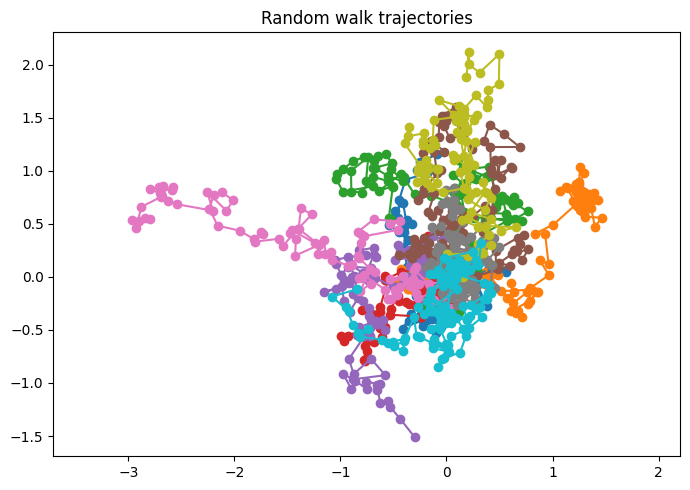

In [255]:
fig, ax = plt.subplots(figsize=(7, 5))

pca_dims = (0, 1)
for i in range(number_of_trajectories):
    trajectory = trajectories[i, :, :]
    (line,) = ax.plot(
        trajectory[:, pca_dims[0]],
        trajectory[:, pca_dims[1]],
        marker="o",
        label=f"Trajectory {i + 1}",
    )

ax.set_title("Random walk trajectories")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

In [264]:
final_positions = trajectories[:, -1, :]
covariance_matrix = torch.cov(final_positions.T)

covariance_matrix.shape

torch.Size([64, 64])

In [265]:
final_positions.shape

torch.Size([1000, 64])

In [266]:
covariance_matrix.diag()

tensor([1.0526, 1.0410, 1.0253, 0.9903, 1.0076, 0.9746, 0.9970, 1.0222, 1.0049,
        1.0014, 1.0266, 1.0076, 0.9371, 0.9642, 0.9808, 0.9666, 0.9885, 1.0274,
        0.9973, 1.0766, 0.9146, 0.9797, 0.9466, 0.9976, 1.0253, 1.0135, 0.9993,
        0.9689, 1.0424, 0.9914, 0.9919, 0.9626, 0.9554, 0.9964, 0.9791, 1.0686,
        1.0705, 1.0187, 0.9681, 1.0131, 0.9881, 0.9853, 1.0388, 0.9924, 0.9704,
        1.0412, 0.9366, 0.9893, 0.9554, 0.9680, 1.0934, 0.9586, 1.0181, 0.9359,
        0.9511, 0.9868, 1.0577, 0.9813, 0.9853, 0.9818, 0.9518, 0.9658, 1.0094,
        0.9352])

In [269]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()

scatter = ax.scatter([], [], alpha=0.5)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel("Dimension 0")
ax.set_ylabel("Dimension 1")


def update(frame):
    scatter.set_offsets(
        trajectories[:, 2*frame, :2].detach().cpu().numpy()
    )
    ax.set_title(f"Step {2*frame + 1}/{trajectories.shape[1]}")
    return (scatter,)


animation = FuncAnimation(
    fig,
    update,
    frames=trajectories.shape[1] // 2,
    interval=50,
    blit=True,
)

plt.close(fig)
HTML(animation.to_jshtml())

TODO: Give intuition and paste https://en.wikipedia.org/wiki/Brownian_motion#/media/File:BMonSphere.jpg

In [236]:
from pep_compass.optimization.components.walkers.strategies.sorbes.geometry.kappa_stable import KappaStableGeometry


sorbes = Sorbes(
    autoencoder=autoencoder,
    boundary=MainBoundary(),
    directions=ActiveInactiveDirections(),
    position_update=MainPositionUpdate(epsilon=0.1, delta_max=0.5),
    scaling=StableDimensionScaling(),
    geometry=KappaStableGeometry(autoencoder, kappa=0.01)
)

In [270]:
peptide_latent

tensor([[-1.5750e+00, -1.4434e-01,  4.7019e-01,  5.4448e-01, -2.5521e-01,
          4.5725e-01, -4.2337e-01, -1.2707e+00,  8.8543e-02,  2.4537e-01,
         -7.0055e-02, -5.3232e-01, -7.5533e+00,  2.3277e-01, -8.2154e-01,
          1.4162e+00,  4.1662e+00,  8.7258e-01, -4.9898e-01,  1.3636e-01,
         -9.3233e-01,  1.7385e+00,  1.3178e+00, -1.6217e-01, -1.8175e-01,
          2.7818e-01,  5.8002e-03, -4.0153e-01, -1.2676e-01, -2.4418e+00,
          1.0282e+00, -6.0231e-01,  2.1893e+00, -2.9909e-01,  2.2059e+00,
          7.3606e-01,  8.8555e-01, -1.8587e+00,  1.4817e+00, -5.2052e-01,
         -2.6043e+00, -3.6220e-01, -8.2669e-01, -7.8342e-01,  1.2272e-01,
         -6.2313e-01,  1.2265e+00,  7.6479e-01, -3.6957e+00,  4.2877e-01,
         -5.5119e-01,  3.2723e-01,  2.5351e+00,  3.8736e-01,  1.2244e+00,
          7.2603e-01,  8.8343e-01, -1.1380e-01,  2.0039e+00,  7.9812e-01,
          7.6816e-01,  2.4274e+00, -7.5730e+00, -2.9302e-01]],
       grad_fn=<AddmmBackward0>)

In [271]:
latent_positions = peptide_latent.repeat(10, 1)

steps = [latent_positions]

for i in range(10):
    sorbes_step_result = sorbes.step(latent_positions)
    steps.append(sorbes_step_result.positions)

steps = torch.stack(steps, dim=0)

In [272]:
x = steps

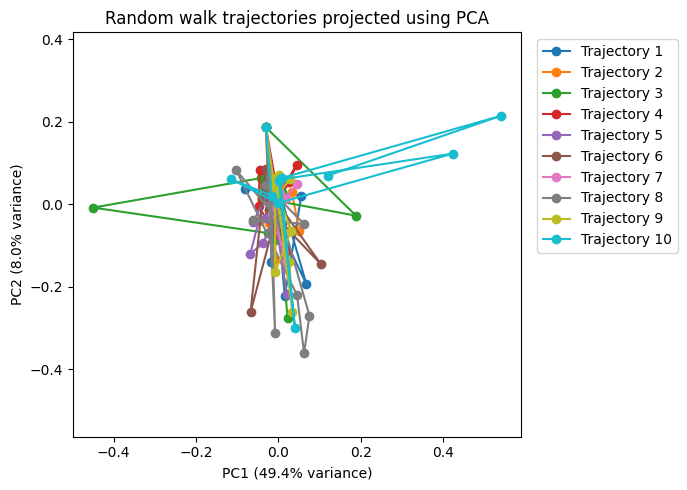

In [273]:
# x.shape == (2, 10, 64)
points = x.detach().cpu().numpy()
n_steps, n_trajectories, n_latent = points.shape

# Treat every step of every trajectory as a sample
pca = PCA(n_components=64)
projected = pca.fit_transform(points.reshape(-1, 64))
projected = projected.reshape(n_steps, n_trajectories, 64)

fig, ax = plt.subplots(figsize=(7, 5))

pca_dims = (2, 1)
for i in range(10):
    trajectory = projected[:, i, :]
    (line,) = ax.plot(
        trajectory[:, pca_dims[0]],
        trajectory[:, pca_dims[1]],
        marker="o",
        label=f"Trajectory {i + 1}",
    )
    # Mark the starting point with a square
    # ax.scatter(*trajectory[0][pca_dims], marker="s", color=line.get_color())

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Random walk trajectories projected using PCA")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

##  📉 Optimization
